<a href="https://colab.research.google.com/github/xmegan10/Reddit-Sentiment-Comment-Prediction/blob/main/Reddit_Comment_Sentiment_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install numpy
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install nltk
%pip install re
%pip install emoji
%pip install contractions
%pip install scikit-learn
%pip install collections
%pip install wordcloud
%pip install pyspark -v

ERROR: Could not find a version that satisfies the requirement re (from versions: none)
ERROR: No matching distribution found for re
ERROR: Could not find a version that satisfies the requirement collections (from versions: none)
ERROR: No matching distribution found for collections
Using pip 24.1.2 from /usr/local/lib/python3.12/dist-packages/pip (python 3.12)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.probability import FreqDist
import re
import emoji #dealing with emojis
import contractions

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

from collections import Counter
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
import os
print(f"Current Working Directory: {os.getcwd()}")

Current Working Directory: /content


In [ ]:
os.listdir()

['.config', 'drive', 'sample_data']

In [ ]:
import torch
torch.cuda.is_available()

False

In [ ]:
from pyspark.sql import SparkSession, Row
spark = SparkSession.builder.appName('Load-jston-to-pyspark-dataframe').getOrCreate()
spark.conf.set("spark.sql.execution.arrow.pyspark.enabled", "true")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
apr_comments = spark.read.json("/content/drive/MyDrive/Colab Notebooks/Reddit Comment Pred/r_AskReddit_commentsApril.jsonl")
apr_posts = spark.read.json("/content/drive/MyDrive/Colab Notebooks/Reddit Comment Pred/r_AskReddit_postsApril.jsonl")

In [ ]:
apr_comments = apr_comments.select("*").toPandas()
apr_posts = apr_posts.select("*").toPandas()

# EDA

In [ ]:
# head of data set
apr_posts.head()

,_meta,all_awardings,allow_live_comments,approved_at_utc,approved_by,archived,author,author_cakeday,author_flair_background_color,author_flair_css_class,...,total_awards_received,treatment_tags,ups,upvote_ratio,url,user_reports,view_count,visited,websocket_url,wls
0,"{'edited_title': None, 'is_edited': None, 'rem...",[],False,None,None,False,534145,None,None,None,...,0,[],1,1.00,https://www.reddit.com/r/AskReddit/comments/1s...,[],None,False,None,6
1,"{'edited_title': None, 'is_edited': None, 'rem...",[],False,None,None,False,Only_Hotel_7221,None,None,None,...,0,[],100,0.88,https://www.reddit.com/r/AskReddit/comments/1s...,[],None,False,None,6
2,"{'edited_title': None, 'is_edited': None, 'rem...",[],False,None,None,False,jts_14,None,None,None,...,0,[],2,1.00,https://www.reddit.com/r/AskReddit/comments/1s...,[],None,False,wss://k8s-lb.wss.redditmedia.com/link/1s94k0r?...,6
3,"{'edited_title': None, 'is_edited': None, 'rem...",[],False,None,None,False,Captain_CrunchYaAss,None,None,None,...,0,[],3,1.00,https://www.reddit.com/r/AskReddit/comments/1s...,[],None,False,wss://k8s-lb.wss.redditmedia.com/link/1s94kun?...,6
4,"{'edited_title': None, 'is_edited': None, 'rem...",[],False,None,None,False,Agile_Wrangler_6731,None,None,None,...,0,[],48,0.94,https://www.reddit.com/r/AskReddit/comments/1s...,[],None,False,wss://k8s-lb.wss.redditmedia.com/link/1s94lab?...,6


In [ ]:
apr_posts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33200 entries, 0 to 33199
Columns: 109 entries, _meta to wls
dtypes: bool(28), float64(1), int64(13), object(67)
memory usage: 21.4+ MB


In [ ]:
apr_posts.columns.tolist()

['_meta',
 'all_awardings',
 'allow_live_comments',
 'approved_at_utc',
 'approved_by',
 'archived',
 'author',
 'author_cakeday',
 'author_flair_background_color',
 'author_flair_css_class',
 'author_flair_richtext',
 'author_flair_template_id',
 'author_flair_text',
 'author_flair_text_color',
 'author_flair_type',
 'author_fullname',
 'author_is_blocked',
 'author_patreon_flair',
 'author_premium',
 'awarders',
 'banned_at_utc',
 'banned_by',
 'can_gild',
 'can_mod_post',
 'category',
 'clicked',
 'content_categories',
 'contest_mode',
 'created',
 'created_utc',
 'discussion_type',
 'distinguished',
 'domain',
 'downs',
 'edited',
 'gilded',
 'hidden',
 'hide_score',
 'id',
 'is_created_from_ads_ui',
 'is_crosspostable',
 'is_meta',
 'is_original_content',
 'is_reddit_media_domain',
 'is_robot_indexable',
 'is_self',
 'is_video',
 'likes',
 'link_flair_background_color',
 'link_flair_css_class',
 'link_flair_richtext',
 'link_flair_template_id',
 'link_flair_text',
 'link_flair_tex

In [ ]:
apr_comments.head()

,_meta,all_awardings,approved_at_utc,approved_by,archived,associated_award,author,author_cakeday,author_flair_background_color,author_flair_css_class,...,subreddit,subreddit_id,subreddit_name_prefixed,subreddit_type,top_awarded_type,total_awards_received,treatment_tags,unrepliable_reason,ups,user_reports
0,"{'is_edited': None, 'removal_type': None, 'ret...",[],None,None,False,None,QuayleDan128,None,None,None,...,AskReddit,t5_2qh1i,r/AskReddit,public,None,0,[],None,1,[]
1,"{'is_edited': None, 'removal_type': None, 'ret...",[],None,None,False,None,_persian_princess_,None,None,None,...,AskReddit,t5_2qh1i,r/AskReddit,public,None,0,[],None,3,[]
2,"{'is_edited': None, 'removal_type': None, 'ret...",[],None,None,False,None,anormalgeek,None,None,None,...,AskReddit,t5_2qh1i,r/AskReddit,public,None,0,[],None,4,[]
3,"{'is_edited': None, 'removal_type': None, 'ret...",[],None,None,False,None,skatefan420,None,None,None,...,AskReddit,t5_2qh1i,r/AskReddit,public,None,0,[],None,2,[]
4,"{'is_edited': None, 'removal_type': None, 'ret...",[],None,None,False,None,ThinkIndependently5,None,None,None,...,AskReddit,t5_2qh1i,r/AskReddit,public,None,0,[],None,1,[]


In [ ]:
apr_comments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 833548 entries, 0 to 833547
Data columns (total 73 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   _meta                            810063 non-null  object
 1   all_awardings                    833548 non-null  object
 2   approved_at_utc                  0 non-null       object
 3   approved_by                      0 non-null       object
 4   archived                         833548 non-null  bool  
 5   associated_award                 0 non-null       object
 6   author                           833548 non-null  object
 7   author_cakeday                   2567 non-null    object
 8   author_flair_background_color    23900 non-null   object
 9   author_flair_css_class           0 non-null       object
 10  author_flair_richtext            809899 non-null  object
 11  author_flair_template_id         0 non-null       object
 12  author_flair_tex

In [ ]:
def create_edadf(*dataframes):
    eda_df = []
    for df in dataframes:
        eda_df.append({
            "name": df.name,
            "num_rows": df.shape[0],
            "num_cols": df.shape[1],
            "contains_null": df.isnull().any(axis = None)
        })
    return pd.DataFrame(eda_df)

p_eda_df = create_edadf(apr_posts)
c_eda_df = create_edadf(apr_comments)

In [ ]:
p_eda_df

,name,num_rows,num_cols,contains_null
0,0 t3_1s94jjw 1 t3_1s94jno 2 ...,33200,109,True


In [ ]:
c_eda_df

,name,num_rows,num_cols,contains_null
0,0 t1_odlodpk 1 t1_odlodp9 2 ...,833548,73,True


In [ ]:
posts_df = apr_posts.copy()
comments_df = apr_comments.copy()

# Split Data into Train and Test

In [ ]:
#remove t3 from link_id in comments_df
comments_df['link_id'] = comments_df['link_id'].str.replace('t3_', '')
comments_df['link_id'].value_counts()

,count
link_id,
1sa3jwv,13149
1sdmusm,9136
1scriio,8994
1sbcji8,8162
1sagz0b,7931
...,...
1sdud7x,1
1rnhted,1
1sdufn6,1


In [ ]:
from sklearn.model_selection import train_test_split
ptrain_set, ptest_set = train_test_split(posts_df, test_size = 0.2, random_state = 42)

#get the list of IDs for each split
ptrain_ids = ptrain_set['id'].unique()
ptest_ids = ptest_set['id'].unique()

ctrain_set = comments_df[comments_df['link_id'].isin(ptrain_ids)]
ctest_set = comments_df[comments_df['link_id'].isin(ptest_ids)]

In [ ]:
ptrain_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26560 entries, 18578 to 15795
Columns: 109 entries, _meta to wls
dtypes: bool(28), float64(1), int64(13), object(67)
memory usage: 17.3+ MB


In [ ]:
ctrain_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 644213 entries, 96 to 833545
Data columns (total 73 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   _meta                            628259 non-null  object
 1   all_awardings                    644213 non-null  object
 2   approved_at_utc                  0 non-null       object
 3   approved_by                      0 non-null       object
 4   archived                         644213 non-null  bool  
 5   associated_award                 0 non-null       object
 6   author                           644213 non-null  object
 7   author_cakeday                   1993 non-null    object
 8   author_flair_background_color    18005 non-null   object
 9   author_flair_css_class           0 non-null       object
 10  author_flair_richtext            626401 non-null  object
 11  author_flair_template_id         0 non-null       object
 12  author_flair_text   

In [ ]:
missing_ids = ctrain_set[~ctrain_set['link_id'].isin(ptrain_set['id'])]['id'].unique()

print(f"Number of unique Post IDs missing from ptrain_setk: {len(missing_ids)}")
print("First 10 missing IDs:", missing_ids[:10])

Number of unique Post IDs missing from ptrain_setk: 0
First 10 missing IDs: []


In [ ]:
#create copies of ptrain_set and ctrain_set to test on pipeline classes
ptrain_set_test = ptrain_set.copy()
ctrain_set_test = ctrain_set.copy()

# Remove Null and One-Unique-only columns


In [ ]:
len(ctrain_set.index)

644213

In [ ]:
def drop_cols(df):
  for c in df.columns:
    # Check if all values are null
    if df[c].isnull().sum() == len(df.index):
      df.drop(c, axis=1, inplace=True)
    else:
      # Try to check for unique values. If TypeError occurs,
      # convert elements to string representation
      try:
        if len(df[c].unique()) == 1:
          df.drop(c, axis=1, inplace=True)
      except TypeError:
        # Handle unhashable types
        # Convert to string to check if all string representations are the same
        if df[c].astype(str).nunique() == 1:
          df.drop(c, axis=1, inplace=True)
  return df

In [ ]:
ptrain_set = drop_cols(ptrain_set)
ctrain_set = drop_cols(ctrain_set)

/tmp/ipykernel_18099/2402450421.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(c, axis=1, inplace=True)
/tmp/ipykernel_18099/2402450421.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(c, axis=1, inplace=True)
/tmp/ipykernel_18099/2402450421.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(c, axis=1, inplace=True)
/tmp/ipykernel_18099/2402450421.py:11: SettingWithCopyWarning: 
A value is trying to be

In [ ]:
ptrain_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26560 entries, 18578 to 15795
Data columns (total 45 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   _meta                          25637 non-null  object 
 1   author                         26560 non-null  object 
 2   author_cakeday                 71 non-null     object 
 3   author_flair_background_color  1572 non-null   object 
 4   author_flair_richtext          24988 non-null  object 
 5   author_flair_text_color        1572 non-null   object 
 6   author_flair_type              24988 non-null  object 
 7   author_fullname                24988 non-null  object 
 8   author_patreon_flair           24988 non-null  object 
 9   author_premium                 24988 non-null  object 
 10  created                        26560 non-null  int64  
 11  created_utc                    26560 non-null  int64  
 12  domain                         26560 non-null  

In [ ]:
ctrain_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 644213 entries, 96 to 833545
Data columns (total 37 columns):
 #   Column                         Non-Null Count   Dtype 
---  ------                         --------------   ----- 
 0   _meta                          628259 non-null  object
 1   author                         644213 non-null  object
 2   author_cakeday                 1993 non-null    object
 3   author_flair_background_color  18005 non-null   object
 4   author_flair_richtext          626401 non-null  object
 5   author_flair_text_color        18005 non-null   object
 6   author_flair_type              626401 non-null  object
 7   author_fullname                626208 non-null  object
 8   author_patreon_flair           626401 non-null  object
 9   author_premium                 626401 non-null  object
 10  body                           644213 non-null  object
 11  collapsed                      644213 non-null  bool  
 12  collapsed_reason               213 non-null     

# Select only relevant columns

In [ ]:
post_features = ["created_utc",
                    "id",
                    "is_crosspostable",
                    "link_flair_text",
                    "link_flair_type",
                    "over_18",
                    "poll_data",
                    "selftext",
                    "spoiler",
                    "thumbnail",
                    "title"]

comment_features = ["body",
                    "created_utc",
                    "distinguished",
                    "id",
                    "link_id",
                    "locked",
                    "parent_id",
                    "score",
                    "stickied",
                    "ups"]

In [ ]:
ptrain_set = ptrain_set[post_features]
ctrain_set = ctrain_set[comment_features]

In [ ]:
ptrain_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26560 entries, 18578 to 15795
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   created_utc       26560 non-null  int64 
 1   id                26560 non-null  object
 2   is_crosspostable  26560 non-null  bool  
 3   link_flair_text   95 non-null     object
 4   link_flair_type   26560 non-null  object
 5   over_18           26560 non-null  bool  
 6   poll_data         1253 non-null   object
 7   selftext          26560 non-null  object
 8   spoiler           26560 non-null  bool  
 9   thumbnail         26454 non-null  object
 10  title             26560 non-null  object
dtypes: bool(3), int64(1), object(7)
memory usage: 1.9+ MB


In [ ]:
ctrain_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 644213 entries, 96 to 833545
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   body           644213 non-null  object
 1   created_utc    644213 non-null  int64 
 2   distinguished  3917 non-null    object
 3   id             644213 non-null  object
 4   link_id        644213 non-null  object
 5   locked         644213 non-null  bool  
 6   parent_id      644213 non-null  object
 7   score          644213 non-null  int64 
 8   stickied       644213 non-null  bool  
 9   ups            644213 non-null  int64 
dtypes: bool(2), int64(3), object(5)
memory usage: 45.5+ MB


## Create FeatureSelector class

In [ ]:
ptrain_set_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26560 entries, 18578 to 15795
Columns: 109 entries, _meta to wls
dtypes: bool(28), float64(1), int64(13), object(67)
memory usage: 17.3+ MB


In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

class FeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, variables = None):
      self.columns_to_drop = []

    def fit(self, X, y = None):
      self.columns_to_drop = []

      for c in list(X.columns):
        if X[c].isnull().all():
          self.columns_to_drop.append(c)
        else:
          try:
            if len(X[c].unique()) == 1:
              self.columns_to_drop.append(c)
          except TypeError:
            if X[c].astype(str).nunique() == 1:
              self.columns_to_drop.append(c)

      return self

    def transform(self, X):
        X = X.copy()
        X.drop(self.columns_to_drop, axis = 1, inplace = True)
        X
        return X

In [ ]:
selector = FeatureSelector()
selector.fit(ptrain_set_test)
ptrain_set_test = selector.transform(ptrain_set_test)
ptrain_set_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26560 entries, 18578 to 15795
Data columns (total 45 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   _meta                          25637 non-null  object 
 1   author                         26560 non-null  object 
 2   author_cakeday                 71 non-null     object 
 3   author_flair_background_color  1572 non-null   object 
 4   author_flair_richtext          24988 non-null  object 
 5   author_flair_text_color        1572 non-null   object 
 6   author_flair_type              24988 non-null  object 
 7   author_fullname                24988 non-null  object 
 8   author_patreon_flair           24988 non-null  object 
 9   author_premium                 24988 non-null  object 
 10  created                        26560 non-null  int64  
 11  created_utc                    26560 non-null  int64  
 12  domain                         26560 non-null  

# Preprocess Text

In [ ]:
ptrain_set[ptrain_set["selftext"] != ""]["selftext"].value_counts()

,count
selftext,
[removed],1115
[deleted],435
[ Removed by Reddit on account of violating the [content policy](/help/contentpolicy). ],7


In [ ]:
#group removed and rename all types
ptrain_set["selftext"] = ptrain_set["selftext"].replace({"":'none','[removed]':'removed','[ Removed by Reddit on account of violating the [content policy](/help/contentpolicy). ]':'removed','[deleted]':'deleted'})

In [ ]:
#rename selftext column to status
ptrain_set = ptrain_set.rename(columns = {"selftext":"status"})

In [ ]:
ptrain_set["status"].value_counts()

,count
status,
none,25003
removed,1122
deleted,435


In [ ]:
#r/AskReddit does not frequently has posts with bodies, so we skip this code for now. In the future if using this code on a subreddit with long bodies, you can use this code:
#combines selftext (body) with title (post title)

#ptrain_set["post_string"] = ptrain_set["post_title"].str.cat(ptrain_set["post_text"], sep = " ",na_rep = "")
#ptrain_set["post_string"].eq("").sum()

In [ ]:
#add meta data to improve training
#add word counts of post_string as pstring_len
ptrain_set["post_length"] = ptrain_set["title"].str.split().str.len()


In [ ]:
ptrain_set[["post_length","title"]]

,post_length,title
18578,14,If the contents of your mind were publicly exp...
22809,12,Why don't Americans make the claim that they a...
24772,8,American people what is your opinion on Belaru...
14417,15,Who would actually want to date Howl from the ...
16771,36,"People who get called calm by people, what is ..."
...,...,...
16850,7,What are your thoughts on vigilante justice?
6265,18,What's a love story you wish you could continu...
11284,12,What’s something you see differently now compa...
860,17,“Stayin’ Alive” turns 50 next year. What newer...


In [ ]:
def preprocess_df(df, text_col = "title"):
    #CLEAN TEXT
    processed_texts = []

    #loading stop words and objects from classes
    default_stopwords = set(stopwords.words('english'))
    default_stopwords.add("edit")
    lmtzr = WordNetLemmatizer()

    def clean_text(sentence):
        #return "" if sentence is NaN so no error occurs
        if not isinstance(sentence, str) or sentence.strip() == "":
            return ""

        #convert emojis to text
        sentence = emoji.demojize(sentence)
        #remove https from strings
        sentence = re.sub(r'http\S+','', sentence)
        #remove new lines
        sentence = re.sub(r'\\n|:|_',' ', sentence)
        #expand contractions
        sentence = contractions.fix(sentence)
        #remove punctuations and lowercase
        sentence = re.sub(r'[^a-zA-Z0-9\s]', '', sentence).lower()


        #tokenize words
        tokens = word_tokenize(sentence)

        final_words = []
        for word in tokens: #for each word in the sentence
            fixed_word = contractions.fix(word) #expand contractions
            if fixed_word not in default_stopwords:
                lemma = lmtzr.lemmatize(fixed_word) #lemmatize words
                final_words.append(lemma) #append the singular lemmatized word to the final_words list

        return ' '.join(final_words) #append the list of words to processed_text

    df[text_col] = df[text_col].apply(clean_text)
    return df

In [ ]:
ptrain_set = preprocess_df(ptrain_set, text_col = "title")

In [ ]:
ptrain_set["title"]

,title
18578,content mind publicly exposed somehow would
22809,american make claim another country
24772,american people opinion belarusrussia
14417,would actually want date howl movie howl movin...
16771,people get called calm people mbti compliment ...
...,...
16850,thought vigilante justice
6265,love story wish could continue end social norm
11284,something see differently compared year ago
860,stayin alive turn 50 next year newer song want...


## Pipeline: FeaturePreprocessor

In [ ]:
#write pipeline for preprocess step
from sklearn.base import BaseEstimator, TransformerMixin

class FeaturePreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, variables = None):
        self.variables = variables

        self.stop_words = set(stopwords.words('english'))
        self.stop_words.add("edit")
        self.lmtzr = WordNetLemmatizer()

    def fit(self, X, y = None):
        return self

    def clean_text(self, text):
        if not isinstance(text, str) or text.strip() == "":
            return ""

        #convert emojis to text
        text = emoji.demojize(text)
        #expand contractions
        text = contractions.fix(text)
        #remove https from strings
        text = re.sub(r'http\S+','', text)
        #remove new lines
        text = re.sub(r'\\n|:|_',' ', text)
        #remove punctuations and lowercase
        text = re.sub(r'[^a-zA-Z0-9\s]', '', text).lower()

        #tokenize words
        tokens = word_tokenize(text)
        cleaned_tokens = [self.lmtzr.lemmatize(word) for word in tokens if word not in self.stop_words]

        return cleaned_tokens


    def transform(self, X):
        X = X.copy()

        #add word counts of post_string as pstring_len
        X["post_length"] = X["title"].str.split().str.len()
        #group removed and rename all types
        X["selftext"] = X["selftext"].replace({"":'none','[removed]':'removed','[ Removed by Reddit on account of violating the [content policy](/help/contentpolicy). ]':'removed','[deleted]':'deleted'})
        #rename selftext column to status
        X = X.rename(columns = {"selftext":"status"})


        X["title"] = X["title"].apply(self.clean_text).str.join(" ")

        return X

In [ ]:
feat_preprocessor = FeaturePreprocessor()
ptrain_set_test = feat_preprocessor.transform(ptrain_set_test)

In [ ]:
ptrain_set_test["title"]

,title
18578,content mind publicly exposed somehow would
22809,american make claim another country
24772,american people opinion belarusrussia
14417,would actually want date howl movie howl movin...
16771,people get called calm people mbti compliment ...
...,...
16850,thought vigilante justice
6265,love story wish could continue end social norm
11284,something see differently compared year ago
860,stayin alive turn 50 next year newer song want...


# Word Frequency Visualizations

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

class FreqVisualizer:
    def __init__(self, df, text_col):
        self.df = df
        self.text_col = text_col
        self.words_ = []
        self.counts_ = []

    def visualize_word_freq(self):
        vectorizer = CountVectorizer(stop_words='english')
        X_counts = vectorizer.fit_transform(self.df[self.text_col])

        w_counts = X_counts.toarray().sum(axis = 0)
        feature_names = vectorizer.get_feature_names_out()

        word_freq = [(word, w_counts[idx])for word, idx in vectorizer.vocabulary_.items()]
        word_freq = sorted(word_freq, key=lambda x: x[1], reverse = True)

        self.words_ = [w[0] for w in word_freq[:30]]
        self.counts_ = [w[1] for w in word_freq[:30]]

        fig, ax = plt.subplots()
        ax.barh(self.words_, self.counts_, align = "center")
        ax.invert_yaxis()
        ax.set_title("Top Word Frequencies")
        plt.show()

    def create_freq_df(self):
        if not self.words_:
            print("Running visualizations first to generate counts...")
            self.visualize_word_freq()

        data = {"Words": self.words_, "Counts": self.counts_}
        word_freq_df = pd.DataFrame(data)
        print(word_freq_df)

    def create_wordcloud(self):
        if self.words_:
            freq_dict = dict(zip(self.words_, self.counts_))
            wordcloud = WordCloud(width = 800, height = 400, background_color= "white").generate_from_frequencies(freq_dict)
        else:
            comment_text = ' '.join(self.df[self.text_col].astype(str))
            wordcloud = WordCloud(width = 800, height = 400, background_color= "white").generate(comment_text)
        plt.figure(figsize = (10,5))
        plt.imshow(wordcloud, interpolation="bilinear")
        plt.axis("off")
        plt.show()

f_vis_pstring = FreqVisualizer(ptrain_set, "title")

In [ ]:
f_vis_cstring = FreqVisualizer(ctrain_set, "body")

In [ ]:
print(len(ptrain_set[ptrain_set["title"] != " "]))
print(len(ptrain_set))

26560
26560


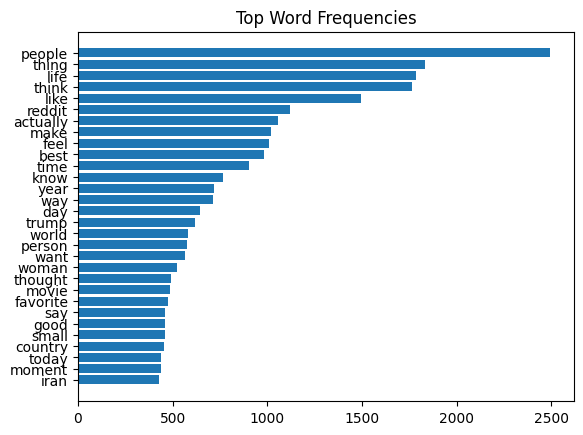

In [ ]:
f_vis_pstring.visualize_word_freq()

In [ ]:
f_vis_pstring.create_freq_df()

       Words  Counts
0     people    2494
1      thing    1830
2       life    1783
3      think    1763
4       like    1496
5     reddit    1120
6   actually    1056
7       make    1021
8       feel    1011
9       best     980
10      time     905
11      know     765
12      year     719
13       way     712
14       day     645
15     trump     619
16     world     581
17    person     574
18      want     566
19     woman     523
20   thought     492
21     movie     488
22  favorite     476
23       say     461
24      good     459
25     small     458
26   country     455
27     today     437
28    moment     436
29      iran     426


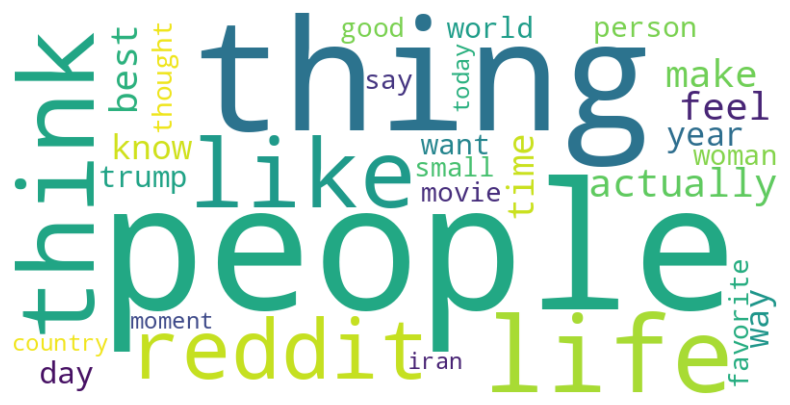

In [ ]:
f_vis_pstring.create_wordcloud()

# Vectorize Post Title Strings

In [ ]:
p_string = ptrain_set["title"]
vectorizer = TfidfVectorizer(lowercase = True,
                             max_features=100,
                             max_df = 0.9, #remove words occuring more than x% time in document
                             min_df = 5, #remove words occur less than x times in doc
                             ngram_range = (1,3), #look for one word up to trigrams
                             stop_words= "english")
vectors = vectorizer.fit_transform(p_string)

In [ ]:
vectors.shape

In [ ]:
vectorizer.vocabulary_

In [ ]:
feature_names = vectorizer.get_feature_names_out()
feature_names

In [ ]:
dense = vectors.todense()
denselist = dense.tolist()

all_keywords = []

for description in denselist:
    x = 0
    keywords = []
    for word in description:
        if word > 0:
            keywords.append(feature_names[x])
        x=x+1
    all_keywords.append(keywords)

print(all_keywords) #the relevant words from tf_idf (value is > 0)

#BERTOPIC Modeling

In [ ]:
%pip install bertopic
%pip install ipywidgets
%pip install SentenceTransformer
%pip install kneed
%pip install torch

In [ ]:
ptrain_set["title"]

In [ ]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
import torch

docs = ptrain_set["title"].tolist()
sentence_model = SentenceTransformer('all-MiniLM-L6-v2')
topic_model = BERTopic(embedding_model=sentence_model)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
embedding_model = sentence_model.to(device)
embeddings = embedding_model.encode(docs)

In [ ]:
umap_reducer = UMAP(random_state= 42)
reduced_embeddings = umap_reducer.fit_transform(embeddings)
print(f"Reduced: {reduced_embeddings.shape}")

In [ ]:
from kneed import KneeLocator
K_MIN, K_MAX = 2, 40
k_range = range(K_MIN, K_MAX + 1)
ssd = []

for k in k_range:
    km = KMeans(n_clusters = k, n_init = 10, random_state = 42)
    km.fit(reduced_embeddings)
    ssd.append(km.inertia_)

kl = KneeLocator(list(k_range), ssd, curve = "convex", direction = "decreasing")
optimal_k = kl.elbow
print(f"Optimal k: {optimal_k}")

fig, ax = plt.subplots(figsize = (10, 6))
ax.plot(list(k_range), ssd, 'o-')
ax.axvline(x=optimal_k, color = "red", linestyle = "--")
ax.set_xlabel('k'); ax.set_ylabel('Inertia'); ax.set_title('Elbow Method'); ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score
test_range = range(max(2, optimal_k - 4), optimal_k + 6)
sil_scores = []

for k in test_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(reduced_embeddings)
    s = silhouette_score(reduced_embeddings, labels, random_state = 42)
    sil_scores.append(s)

best_k_sil = list(test_range)[np.argmax(sil_scores)]
print(f"Best by silhouette: k={best_k_sil}")

fig, ax = plt.subplots(figsize = (10, 6))
ax.bar(list(test_range), sil_scores, edgecolor = "white")
ax.set_xlabel('k'); ax.set_ylabel('Scores'); ax.set_title('Silhouette Scores'); ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

In [ ]:
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic.representation import KeyBERTInspired
from bertopic.representation import MaximalMarginalRelevance

K_A = optimal_k
K_B = best_k_sil
k_values = sorted(set([K_A, K_B]))
k_values = [int(k) for k in k_values]

vectorizer_model = CountVectorizer(min_df = 5, ngram_range=(1,2), stop_words = "english")
representation_model = KeyBERTInspired()
representation_model = MaximalMarginalRelevance(diversity = 0.3)

k_values

In [ ]:
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_reducer,
    hdbscan_model=KMeans(n_clusters = K_A, n_init=10, random_state=42),
    vectorizer_model=vectorizer_model,
    representation_model=representation_model,
    verbose=True
)

t,p = topic_model.fit_transform(docs, embeddings=embeddings)
topic_model.get_topic_info()


In [ ]:
topic_model.get_topics()

In [ ]:
ptrain_set.info()

In [ ]:
ptrain_setk = ptrain_set.copy()
ptrain_setk['topic'] = topic_model.topics_

#apply topic string name to ptrain_setk
topic_info = topic_model.get_topic_info()
topic_map = dict(zip(topic_info.Topic, topic_info.Name))
ptrain_setk['topic_label'] = ptrain_setk['topic'].map(topic_map)

In [ ]:
ptrain_setk.head()

## BERTopicClusterer class

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

class BERTopicClusterer(BaseEstimator, TransformerMixin):
    def __init__(self, kmin=2, kmax=40):
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'

        self.kmin = kmin
        self.kmax = kmax

        self.umap_reducer = UMAP(n_neighbors = 15, n_components = 5, min_dist = 0.0, metric = 'cosine', random_state = 42)
        self.sentence_model = SentenceTransformer('all-MiniLM-L6-v2', device = self.device)
        self.vectorizer_model = CountVectorizer(min_df = 5, ngram_range=(1,2), stop_words = "english")
        self.representation_model = [KeyBERTInspired(), MaximalMarginalRelevance(diversity=0.3)]

        self.topic_model = None

    def fit(self, X, y = None):
        docs = X["title"].tolist()
        embeddings = self.sentence_model.encode(docs, show_progress_bar = True)

        reduced_embeddings = self.umap_reducer.fit_transform(embeddings)

        k_range = range(self.kmin, self.kmax + 1)
        ssd = []
        for k in k_range:
            km = KMeans(n_clusters = k, n_init = 10, random_state = 42)
            km.fit(reduced_embeddings)
            ssd.append(km.inertia_)

        kl = KneeLocator(list(k_range), ssd, curve = "convex", direction = "decreasing")
        optimal_k = kl.elbow if kl.elbow else self.kmin

        self.topic_model = BERTopic(
            embedding_model=self.sentence_model,
            umap_model=self.umap_reducer,
            hdbscan_model=KMeans(n_clusters = optimal_k, n_init=10, random_state=42),
            vectorizer_model=self.vectorizer_model,
            representation_model=self.representation_model,
            verbose=True
        )

        self.topic_model.fit_transform(docs, embeddings = embeddings)
        return self

    def transform(self, X):

        X = X.copy()

        docs = X["title"].tolist()

        topics, _ = self.topic_model.transform(docs)
        X['topics'] = topics

        topic_info = self.topic_model.get_topic_info()
        topic_map = dict(zip(topic_info.Topic, topic_info.Name))
        X['topic_label'] = X['topics'].map(topic_map)

        return X

In [ ]:
bertopic_cluster = BERTopicClusterer()
bertopic_cluster.fit(ptrain_set_test)
ptrain_set_test = bertopic_cluster.transform(ptrain_set_test)

In [ ]:
ptrain_set_test.info()

In [ ]:
ptrain_set_test["topics"]

# Sentiment Score (Hugging Face)

In [ ]:
%pip install -q transformers
%pip install dotenv
%pip install requests
%pip install tqdm


In [ ]:
from transformers import pipeline, AutoTokenizer, AutoConfig, AutoModelForSequenceClassification, AutoModel

model_name= "cardiffnlp/twitter-roberta-base-sentiment"
config = AutoConfig.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

device = 0 if torch.cuda.is_available else -1
print(device)

classifier = pipeline('sentiment-analysis', model=model, tokenizer=tokenizer, config = config, device = device)

In [ ]:
torch.cuda.is_available()

In [ ]:
from tqdm.auto import tqdm

#uncomment code below on the final test

c_df_scores = ctrain_set.copy()

#0 = negative, 1 = neutral, 2 = positive
label_map = {
    "LABEL_0": "Negative",
    "LABEL_1": "Neutral",
    "LABEL_2": "Positive",
}

def run_classification(df, col = "body", batch_size = 32):
    data_loader = df[col].astype(str).tolist()

    labels = []
    scores = []

    for res in tqdm(classifier(data_loader, max_length = 512, truncation = True, batch_size = batch_size), total = len(df)):
        labels.append(label_map.get(res['label'], res['label']))
        scores.append(res['score'])

    df['sent_label'] = labels
    df['sent_score'] = scores
    return df

result = run_classification(c_df_scores)
result.head()

In [ ]:
result["sent_label"].value_counts()

In [ ]:
#add result df as a csv to google drive

result.to_csv("comment_sent.csv", index = False)
!cp comment_sent.csv "/content/drive/My Drive/Colab Notebooks/Reddit Comment Pred"

In [ ]:
result_csv = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Reddit Comment Pred/comment_sent.csv")

In [ ]:
result_csv["sent_label"].value_counts()

In [ ]:
result_csv.head()

In [ ]:
#merge sent_label and sent_score from result_csv to ctrain_set
ctrain_set = ctrain_set.merge(
    result_csv[["comment_id","sent_label","sent_score"]],
    on="comment_id",
    how="left"
)

ctrain_set.head()

## SentScorer class

In [ ]:
from tqdm.auto import tqdm
from transformers import pipeline, AutoTokenizer, AutoConfig, AutoModelForSequenceClassification, AutoModel

class SentScorer(TransformerMixin, BaseEstimator):
    def __init__(self, model_name="cardiffnlp/twitter-roberta-base-sentiment"):
        self.device = 0 if torch.cuda.is_available() else -1
        #0 = negative, 1 = neutral, 2 = positive
        self.label_map = {
            "LABEL_0": "Negative",
            "LABEL_1": "Neutral",
            "LABEL_2": "Positive"
        }

        self.model_name = model_name
        self.config = AutoConfig.from_pretrained(model_name)
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForSequenceClassification.from_pretrained(model_name)

        self.classifier = pipeline('sentiment-analysis',
                                   model = self.model,
                                   tokenizer = self.tokenizer,
                                   config = self.config,
                                   device = self.device)
    def fit(self, X, y = None):
        return self

    def transform(self, X):
        c_df_scores = X.copy()

        data_loader = c_df_scores["body"].astype(str).tolist()

        labels = []
        scores = []

        results = self.classifier(data_loader,
                                  max_length = 512,
                                  truncation = True,
                                  batch_size = 32)

        for res in tqdm(results, total = len(data_loader), desc = "Scoring Sentiment"):
            labels.append(self.label_map.get(res['label'], res['label']))
            scores.append(res['score'])

        c_df_scores['sent_label'] = labels
        c_df_scores['sent_score'] = scores

        return c_df_scores

In [ ]:
sent_scorer = SentScorer()
ctrain_set_test = sent_scorer.transform(ctrain_set_test)

In [ ]:
ctrain_set_test.head()

# Prepare for ML